# 02 — เลือกแหล่ง target (Open-Meteo vs NASA POWER) ด้วยข้อมูลตรวจสอบปี 2023

**กฎ:** notebook นี้ใช้ได้เฉพาะ TEMIS/OMI **ปี 2023** (split `select`) ผ่าน `load_validation()` เท่านั้น
ข้อมูลปี 2024–2025 เก็บไว้เป็น holdout สำหรับวัน 10 ห้ามโหลดหรือดูก่อนถึงวันนั้น

**กฎตัดสิน (ประกาศไว้ก่อนดูผล):**
1. ตัวชี้วัดหลักคือ MAE ของ UVI ฟ้ามีเมฆเทียบกับ OMI `UVindex` ตอนเที่ยงสุริยะ เพราะ target ของโมเดลคือ UVI ในสภาพฟ้าจริง
2. ถ้า MAE ของสองแหล่งต่างกันไม่ถึง 0.3 UVI ให้เลือก Open-Meteo เพราะเป็นรายชั่วโมงและมีคู่ clear-sky สำหรับคำนวณ CMF ได้โดยตรง
3. ค่าเทียบกับ TEMIS/OMI ฟ้าใส ใช้เป็นข้อมูลประกอบ (ตรวจแบบจำลองฟ้าใส) ไม่ได้ใช้ตัดสิน

**ข้อจำกัด:** OMI เป็นพิกเซลขนาด 1° (~110 กม.) และวัดเพียงครั้งเดียวต่อวันตอนดาวเทียมผ่าน ทราบกันว่าประเมินค่าสูงเกินในพื้นที่ที่มีฝุ่นละอองมาก (absorbing aerosol) ส่วน TEMIS สถานี Bangkok มีเฉพาะค่าฟ้าใส

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
from src.fetch_validation import load_validation
from src.metrics import error_metrics
from src.preprocess import solar_noon_values

train = pd.read_parquet(ROOT / "dataset" / "processed" / "train_merged.parquet")
train = train[train["time_utc"].dt.year == 2023]
noon = solar_noon_values(train, ["uv_index", "uv_index_clear_sky", "nasa_uvi", "nasa_cloud_pct"])
print(len(noon), "days of 2023 with noon values")

temis = load_validation("temis")  # split="select" -> 2023 only
try:
    omi = load_validation("omi")
except FileNotFoundError:
    omi = None
    print("OMI 2023 not downloaded yet: run `python -m src.fetch_validation` after adding Earthdata credentials to .env")

v = noon.merge(temis[["date", "uvi_clear"]], on="date", how="left")
if omi is not None:
    v = v.merge(omi[["date", "UVindex", "CSUVindex"]], on="date", how="left")
clear_day = v["nasa_cloud_pct"] < 10
print("NASA clear-sky days (cloud < 10 % at noon):", int(clear_day.sum()))

365 days of 2023 with noon values
OMI 2023 not downloaded yet: run `python -m src.fetch_validation` after adding Earthdata credentials to .env
NASA clear-sky days (cloud < 10 % at noon): 71


## ตาราง MAE / bias / RMSE / r (bias = แหล่ง − reference, หน่วย UVI)

In [3]:
rows = []


def add(source, variable, reference, pred, ref, subset="all days"):
    rows.append({"source": source, "variable": variable, "reference": reference,
                 "subset": subset, **error_metrics(pred, ref)})


if omi is not None:
    add("Open-Meteo", "uv_index", "OMI UVindex (all-sky)", v["uv_index"], v["UVindex"])
    add("NASA POWER", "nasa_uvi", "OMI UVindex (all-sky)", v["nasa_uvi"], v["UVindex"])
    add("Open-Meteo", "uv_index_clear_sky", "OMI CSUVindex (clear-sky)", v["uv_index_clear_sky"], v["CSUVindex"])
    add("NASA POWER", "nasa_uvi", "OMI CSUVindex (clear-sky)", v.loc[clear_day, "nasa_uvi"],
        v.loc[clear_day, "CSUVindex"], "NASA cloud < 10 %")
add("Open-Meteo", "uv_index_clear_sky", "TEMIS UVIEF (clear-sky)", v["uv_index_clear_sky"], v["uvi_clear"])
add("NASA POWER", "nasa_uvi", "TEMIS UVIEF (clear-sky)", v.loc[clear_day, "nasa_uvi"],
    v.loc[clear_day, "uvi_clear"], "NASA cloud < 10 %")

table = pd.DataFrame(rows)
table.to_csv(ROOT / "docs" / "source_selection_2023.csv", index=False)
table.round(3)

,source,variable,reference,subset,n,mae,bias,rmse,r
0,Open-Meteo,uv_index_clear_sky,TEMIS UVIEF (clear-sky),all days,365,3.500,-3.500,3.626,0.938
1,NASA POWER,nasa_uvi,TEMIS UVIEF (clear-sky),NASA cloud < 10 %,71,2.679,-2.679,3.090,0.551


## กราฟเทียบกับ TEMIS ฟ้าใส (2023)

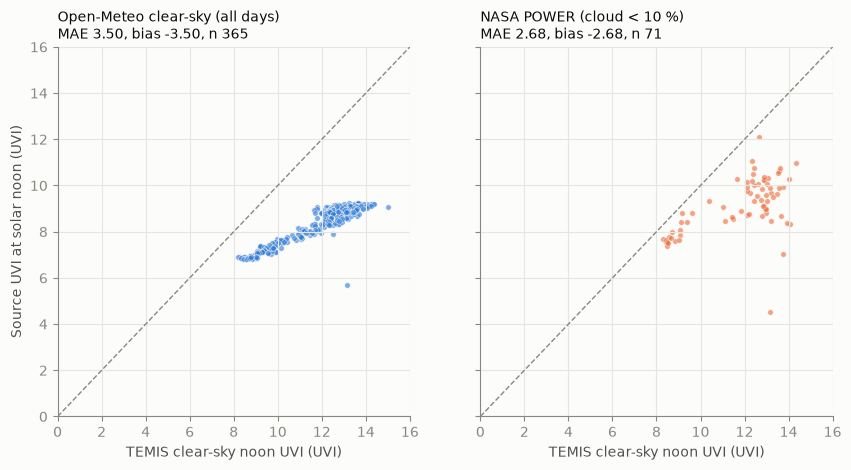

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharex=True, sharey=True)
pairs = [(axes[0], v["uv_index_clear_sky"], v["uvi_clear"], C_OM, "Open-Meteo clear-sky (all days)"),
         (axes[1], v.loc[clear_day, "nasa_uvi"], v.loc[clear_day, "uvi_clear"], C_NASA, "NASA POWER (cloud < 10 %)")]
lim = 16
for ax, x, y, color, title in pairs:
    m = error_metrics(x, y)
    ax.scatter(y, x, s=16, color=color, alpha=0.6, edgecolors="#fcfcfb", linewidths=0.5)
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f"{title}\nMAE {m['mae']:.2f}, bias {m['bias']:+.2f}, n {m['n']}", loc="left", fontsize=10)
    ax.set_xlabel("TEMIS clear-sky noon UVI (UVI)")
axes[0].set_ylabel("Source UVI at solar noon (UVI)")
save(fig, "sel_temis_2023.png")

## กราฟเทียบกับ OMI ฟ้ามีเมฆ (2023)

In [5]:
if omi is None:
    print("skipped: OMI 2023 not available yet")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharex=True, sharey=True)
    for ax, col, color, title in [(axes[0], "uv_index", C_OM, "Open-Meteo all-sky"),
                                  (axes[1], "nasa_uvi", C_NASA, "NASA POWER all-sky")]:
        m = error_metrics(v[col], v["UVindex"])
        ax.scatter(v["UVindex"], v[col], s=16, color=color, alpha=0.6, edgecolors="#fcfcfb", linewidths=0.5)
        ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_title(f"{title}\nMAE {m['mae']:.2f}, bias {m['bias']:+.2f}, n {m['n']}", loc="left", fontsize=10)
        ax.set_xlabel("OMI UVindex at solar noon (UVI)")
    axes[0].set_ylabel("Source UVI at solar noon (UVI)")
    save(fig, "sel_omi_2023.png")

skipped: OMI 2023 not available yet


## การตัดสิน

In [6]:
THRESHOLD = 0.3
if omi is None:
    decision = None
    print("ยังตัดสินไม่ได้: ต้องใช้ OMI 2023 เป็นตัวชี้วัดหลัก ตอนนี้มีเฉพาะผลเทียบฟ้าใสกับ TEMIS")
else:
    main_rows = table[table["reference"] == "OMI UVindex (all-sky)"].set_index("source")
    mae_om, mae_nasa = main_rows.loc["Open-Meteo", "mae"], main_rows.loc["NASA POWER", "mae"]
    if mae_nasa < mae_om - THRESHOLD:
        decision = "NASA POWER"
    else:
        decision = "Open-Meteo"
    print(f"MAE vs OMI: Open-Meteo {mae_om:.3f}, NASA POWER {mae_nasa:.3f} -> target source: {decision}")
decision

ยังตัดสินไม่ได้: ต้องใช้ OMI 2023 เป็นตัวชี้วัดหลัก ตอนนี้มีเฉพาะผลเทียบฟ้าใสกับ TEMIS


## สรุป
ผลการตัดสินดูได้จากเซลล์ด้านบน (ตัดสินตามกฎที่ประกาศไว้ตอนต้น) ตารางเต็มบันทึกไว้ที่ `docs/source_selection_2023.csv`
- ถ้า OMI ยังไม่มี: ผลตอนนี้มีเฉพาะการเทียบฟ้าใสกับ TEMIS ซึ่งยังตัดสินไม่ได้ ต้องใส่ Earthdata credentials ใน `.env` แล้วรัน `python -m src.fetch_validation` จากนั้นรัน notebook นี้ใหม่
- ข้อมูลปี 2024–2025 ยังไม่ถูกโหลดหรือดูใน notebook นี้